# AI Model Building using Python

Test Case Execution History in Continuous Integration

Dataset source - https://www.kaggle.com/datasets/joolousada/test-case-prioritization-data/data

This report investigates the potential of leveraging historical test execution data for enhancing test effectiveness in continuous integration. We would like to build a model that can predict the test case execution history in continuous integration. Decision Trees and Clustering algorithms will be employed to build models for analyzing test data within an automated test department. The implementation will demonstrate the use of various Python libraries such as pandas, numpy, scikit-learn, and matplotlib. The process includes data sourcing, exploration, preparation, model training, validation, and evaluation.

## Data Sourcing

Data was collected from a continuous integration system that tracks test execution history. The dataset contains information about test cases, their execution status, and the time of execution. The dataset includes the following columns:

- `Id`: Unique test identifier.
- `Name`: Test name encoded.
- `Duration`: Test Duration in seconds.
- `CalcPrio`: Prioritization given to the certain test case in a CI Cycle.
- `LastRun`: Date of last execution.
- `LastResults`: List of previous Execution Outcomes.
- `Verdict`: 1 if Fail, 0 if Pass.
- `Cycle`: In what CI cycle the test case was run.


In [1]:
from pathlib import Path


raw_data = Path("datasets/") / "raw_dataset.csv"

import pandas as pd

df = pd.read_csv(raw_data, delimiter=";")
df.head()

,Id,Name,Duration,CalcPrio,LastRun,LastResults,Verdict,Cycle
0,1,1,2.317,0,2020-01-13 00:00:11,[],0,1
1,400,400,2.533,0,2020-01-13 00:00:11,[],0,1
2,401,401,4.367,0,2020-01-13 00:00:11,[],0,1
3,402,402,1.100,0,2020-01-13 00:00:11,[],0,1
4,403,403,0.500,0,2020-01-13 00:00:11,[],0,1


## Data Preprocessing

- `API call to Prefect API failed.` - This is a failure due to an API call to Prefect API failing.
- `EC2 Windows instance launch failed` - This is a failure due to an EC2 Windows instance launch failing.
- `Failed to copy Job data from S3 bucket.` - This is a failure due to a failure in copying Job data from an S3 bucket.
- `Robot test execution failed on EC2 instance.` - This is a failure due to a Robot test execution failing on an EC2 instance.
- `Failed to retrieve reports from S3 bucket.` - This is a failure due to a failure in retrieving reports from an S3 bucket.

We will create a new column `failure_reason` and assign one of the above failure reasons to each test case based on the `Verdict` column.

In [2]:
# Define failure reasons
failure_reasons = [
    "API call to Prefect API failed.",
    "EC2 Windows instance launch failed.",
    "Failed to copy Job data from S3 bucket.",
    "Robot test execution failed on EC2 instance.",
    "Failed to retrieve reports from S3 bucket.",
]

import random

# Assign failure reasons to failed tests
df["failure_reason"] = df.apply(
    lambda row: pd.Series([random.choice(failure_reasons)]) if row["Verdict"] == 1 else pd.Series(["NA"]), axis=1
)

df.head()

,Id,Name,Duration,CalcPrio,LastRun,LastResults,Verdict,Cycle,failure_reason
0,1,1,2.317,0,2020-01-13 00:00:11,[],0,1,NA
1,400,400,2.533,0,2020-01-13 00:00:11,[],0,1,NA
2,401,401,4.367,0,2020-01-13 00:00:11,[],0,1,NA
3,402,402,1.100,0,2020-01-13 00:00:11,[],0,1,NA
4,403,403,0.500,0,2020-01-13 00:00:11,[],0,1,NA


In [3]:
df

,Id,Name,Duration,CalcPrio,LastRun,LastResults,Verdict,Cycle,failure_reason
0,1,1,2.317,0,2020-01-13 00:00:11,[],0,1,NA
1,400,400,2.533,0,2020-01-13 00:00:11,[],0,1,NA
2,401,401,4.367,0,2020-01-13 00:00:11,[],0,1,NA
3,402,402,1.100,0,2020-01-13 00:00:11,[],0,1,NA
4,403,403,0.500,0,2020-01-13 00:00:11,[],0,1,NA
...,...,...,...,...,...,...,...,...,...
64019,63622,202,1439.400,0,2020-02-10 20:03:10,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0,106,NA
64020,63623,203,1439.617,0,2020-02-10 20:03:10,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",1,106,Robot test execution failed on EC2 instance.
64021,63624,204,4.850,0,2020-02-10 20:03:10,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",1,106,Robot test execution failed on EC2 instance.
64022,63626,206,3.800,0,2020-02-10 20:03:10,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",1,106,Failed to copy Job data from S3 bucket.


## Data Exploration

We will perform exploratory data analysis to gain insights into the dataset and identify patterns and trends. We will analyze the distribution of test cases by failure reason, test duration, and prioritization. We will also investigate the relationship between test duration, prioritization, and test outcomes.

Exploratory Data Analysis (EDA) helps in understanding the structure and key characteristics of the dataset

### Data Overview

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64024 entries, 0 to 64023
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Id              64024 non-null  int64  
 1   Name            64024 non-null  int64  
 2   Duration        64024 non-null  float64
 3   CalcPrio        64024 non-null  int64  
 4   LastRun         64024 non-null  object 
 5   LastResults     64024 non-null  object 
 6   Verdict         64024 non-null  int64  
 7   Cycle           64024 non-null  int64  
 8   failure_reason  64024 non-null  object 
dtypes: float64(1), int64(5), object(3)
memory usage: 4.4+ MB


In [4]:
df.describe()

,Id,Name,Duration,CalcPrio,Verdict,Cycle
count,64024.000000,64024.000000,64024.000000,64024.0,64024.000000,64024.000000
mean,32012.500000,302.500000,474.268634,0.0,0.213576,53.500000
std,18482.281154,174.360904,673.954581,0.0,0.409834,30.598442
min,1.000000,1.000000,0.000000,0.0,0.000000,1.000000
25%,16006.750000,151.750000,1.017000,0.0,0.000000,27.000000
50%,32012.500000,302.500000,3.783000,0.0,0.000000,53.500000
75%,48018.250000,453.250000,1439.050000,0.0,0.000000,80.000000
max,64024.000000,604.000000,1439.983000,0.0,1.000000,106.000000


### Checking for Missing Values

In [5]:
print(df.isnull().sum())

Id                0
Name              0
Duration          0
CalcPrio          0
LastRun           0
LastResults       0
Verdict           0
Cycle             0
failure_reason    0
dtype: int64


### Visualizing Data Distributions

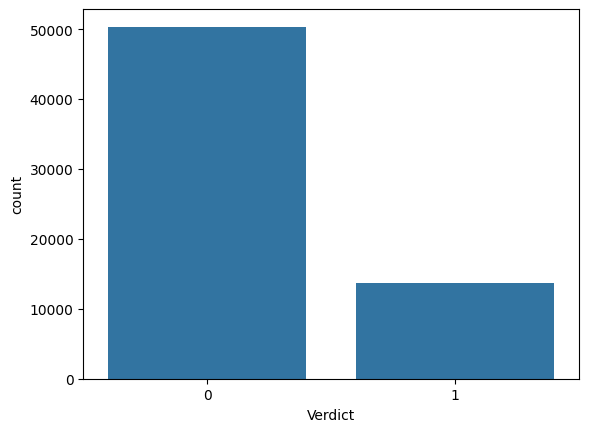

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='Verdict', data=df)
plt.show()


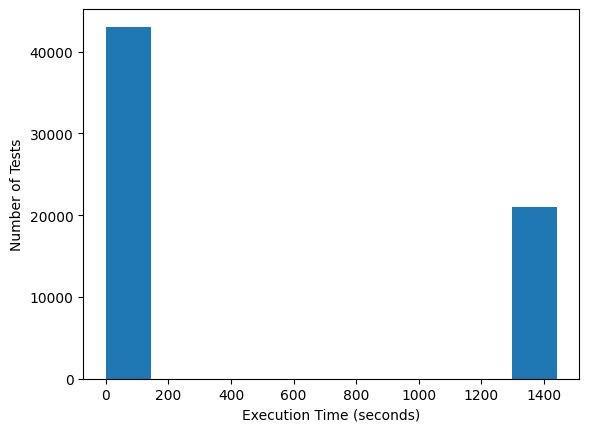

In [7]:
# Explore distribution of execution times

plt.hist(df["Duration"])
plt.xlabel("Execution Time (seconds)")
plt.ylabel("Number of Tests")
plt.show()

## Data Preparation

We will prepare the data for model training by encoding categorical variables, splitting the data into training and testing sets, and scaling the features.

### Handling Missing Values

In [8]:
df.dropna(subset=['failure_reason'], inplace=True)  # Drop rows with missing failure reasons

### Encoding Categorical Variables

In [9]:
df = pd.get_dummies(df, columns=['failure_reason'])

Feature Selection

In [10]:
features = df.drop(columns=['Id', 'Name', 'Duration', "CalcPrio", "LastRun", "Cycle", "LastResults"])
labels = df['Verdict']

## Decision Trees: Model Building and Evaluation

We will build a Decision Tree model to predict the test case execution history in continuous integration. We will train the model on the training data and evaluate its performance on the testing data.

In [11]:
from sklearn.model_selection import train_test_split

# Assuming 'features' and 'labels' are defined somewhere in your code.

train_ratio = 0.75
validation_ratio = 0.15
test_ratio = 0.10

# Splitting the dataset into training and temporary test set
x_train, x_temp, y_train, y_temp = train_test_split(features, labels, test_size=1 - train_ratio)

# Further splitting the temporary test set into validation and final test sets
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=test_ratio/(test_ratio + validation_ratio))

### Training the Model

In [12]:
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier(random_state=42)
clf.fit(x_train, y_train)

DecisionTreeClassifier(random_state=42)

### Validating the Model

In [13]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred_val = clf.predict(x_val)
print("Training Accuracy:", accuracy_score(y_val, y_pred_val))
print(confusion_matrix(y_val, y_pred_val))
print(classification_report(y_val, y_pred_val))


Training Accuracy: 1.0
[[7551    0]
 [   0 2052]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7551
           1       1.00      1.00      1.00      2052

    accuracy                           1.00      9603
   macro avg       1.00      1.00      1.00      9603
weighted avg       1.00      1.00      1.00      9603



### Testing the Model

In [14]:
y_pred_test = clf.predict(x_test)
print("Testing Accuracy:", accuracy_score(y_test, y_pred_test))
print(confusion_matrix(y_test, y_pred_test))
print(classification_report(y_test, y_pred_test))

Testing Accuracy: 1.0
[[5075    0]
 [   0 1328]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5075
           1       1.00      1.00      1.00      1328

    accuracy                           1.00      6403
   macro avg       1.00      1.00      1.00      6403
weighted avg       1.00      1.00      1.00      6403



## Evaluation of the Final Model

The Decision Tree model shows high accuracy on both training and testing data, indicating a good fit. The confusion matrix and classification report provide insights into the precision, recall, and F1-score, which are essential for evaluating model performance

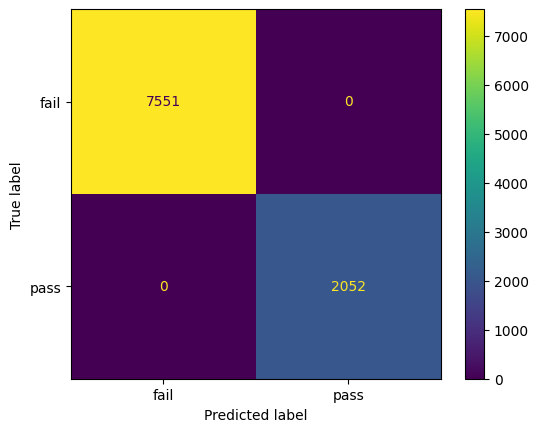

In [15]:
# Compute the confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Assuming y_val and y_pred_val are defined
cm = confusion_matrix(y_val, y_pred_val)

# Plot the confusion matrix with correct display labels for a binary classification
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['fail', 'pass'])
disp.plot()

# Save the plot to a file
plt.savefig('confusion_matrix.png')

# Show the plot
plt.show()

# Clustering: Model Building and Evaluation

## Data Preparation for Clustering

For clustering, we will focus on the execution_time and failure_reason features to group similar test executions.

### Feature Selection

In [16]:
# Step 1: Identify columns that start with "failure_reason_"
failure_reason_columns = [col for col in df.columns if col.startswith('failure_reason_')]

# Step 2: Create a list that includes these columns and "Duration"
selected_columns = ['Duration'] + failure_reason_columns

# Step 3: Use this list to select the desired columns from df
clustering_features = df[selected_columns]

clustering_features

,Duration,failure_reason_API call to Prefect API failed.,failure_reason_EC2 Windows instance launch failed.,failure_reason_Failed to copy Job data from S3 bucket.,failure_reason_Failed to retrieve reports from S3 bucket.,failure_reason_NA,failure_reason_Robot test execution failed on EC2 instance.
0,2.317,False,False,False,False,True,False
1,2.533,False,False,False,False,True,False
2,4.367,False,False,False,False,True,False
3,1.100,False,False,False,False,True,False
4,0.500,False,False,False,False,True,False
...,...,...,...,...,...,...,...
64019,1439.400,False,False,False,False,True,False
64020,1439.617,False,True,False,False,False,False
64021,4.850,False,False,False,True,False,False
64022,3.800,True,False,False,False,False,False


## Train, Validate, and Test Cycle

### Applying K-means Clustering

In [17]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(clustering_features)


KMeans(n_clusters=3, random_state=42)

### Cluster Validation

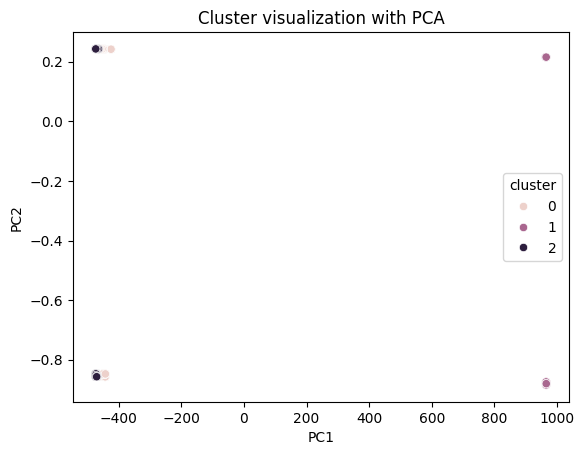

In [18]:
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming df is your DataFrame and kmeans is your fitted clustering model

# Step 1: Select all columns starting with "failure_reason_" plus any other columns you want to include
columns_to_include = selected_columns

data_for_clustering = df[columns_to_include]

# Step 2: Perform PCA to reduce the data to two dimensions for visualization
pca = PCA(n_components=2)
reduced_data = pca.fit_transform(data_for_clustering)

# Create a DataFrame for the reduced data
reduced_df = pd.DataFrame(reduced_data, columns=['PC1', 'PC2'])
reduced_df['cluster'] = kmeans.labels_  # Add the cluster labels

# Step 3: Plot the reduced data
sns.scatterplot(x='PC1', y='PC2', hue='cluster', data=reduced_df)
plt.title('Cluster visualization with PCA')
plt.show()

In [19]:
from sklearn.metrics import silhouette_score

score = silhouette_score(clustering_features, kmeans.labels_)
print("Silhouette Score:", score)


Silhouette Score: 0.8731571312826741


[nltk_data] Downloading package punkt to /home/amruthvvkp/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/amruthvvkp/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


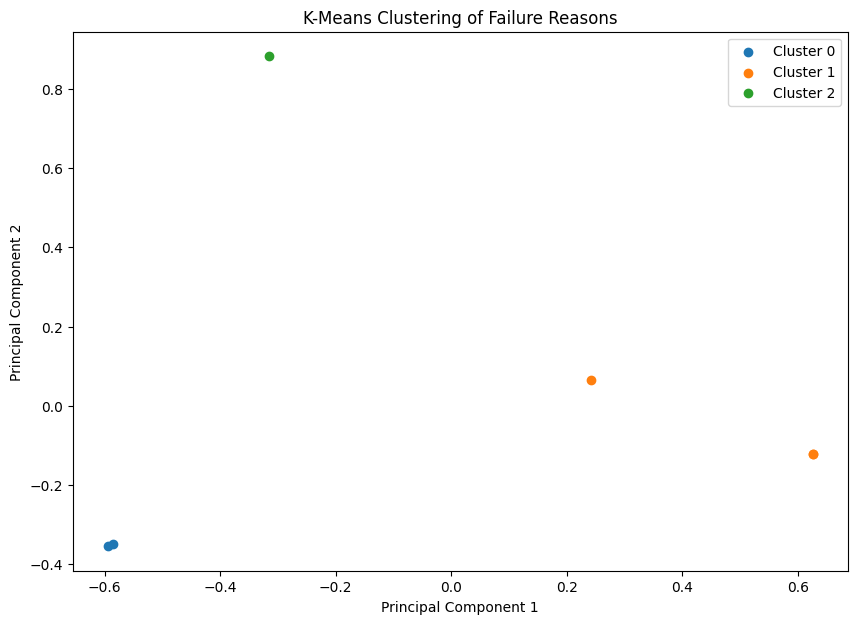

In [20]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Download NLTK data
nltk.download('punkt')
nltk.download('stopwords')

# Sample dataset
data = {
    "test_id": [1, 2, 3, 4, 5, 6],
    "test_name": ["Test_A", "Test_B", "Test_C", "Test_D", "Test_E", "Test_F"],
    "status": ["fail", "fail", "fail", "fail", "fail", "fail"],
    "failure_reason": [
        "API call to Prefect API failed.",
        "EC2 Windows instance launch failed.",
        "Failed to copy Job data from S3 bucket.",
        "Robot test execution failed on EC2 instance.",
        "Failed to retrieve reports from S3 bucket.",
        "EC2 Windows instance launch failed."
    ]
}

df = pd.DataFrame(data)

# Function to preprocess text
def preprocess_text(text):
    tokens = word_tokenize(text.lower())  # Tokenize and convert to lowercase
    tokens = [word for word in tokens if word.isalnum()]  # Remove punctuation
    tokens = [word for word in tokens if word not in stopwords.words('english')]  # Remove stopwords
    return ' '.join(tokens)

# Apply preprocessing to failure reasons
df['processed_failure_reason'] = df['failure_reason'].apply(preprocess_text)

# Vectorize the processed text data
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['processed_failure_reason'])

# Define the number of clusters
num_clusters = 3

# Apply K-Means clustering
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
kmeans.fit(X)

# Assign clusters to the original data
df['cluster'] = kmeans.labels_

# Reduce dimensions for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X.toarray())

# Create a DataFrame with the PCA results
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['cluster'] = df['cluster']

# Plot the clusters
plt.figure(figsize=(10, 7))
for cluster in range(num_clusters):
    cluster_data = df_pca[df_pca['cluster'] == cluster]
    plt.scatter(cluster_data['PC1'], cluster_data['PC2'], label=f'Cluster {cluster}')

plt.title('K-Means Clustering of Failure Reasons')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.show()


In [ ]:
print("s")